In [1]:
%load_ext autoreload
%autoreload 2

In [5]:
import torch
import os
import sys
sys.path.append('/sdcc/u/smccue/projects/inr_sampling')
from torch_geometric.data import Dataset, Data
from torch.utils.data import DataLoader
# from torch_geometric.loader import DataLoader
import argparse
from train_utility_sampling.train_utility import (
    split_graph_by_time,
    train_step,
    validation_step, 
    save_sampling_result,
    train_step_single_image,
    )
from utils.data.unstructure_dataset import (
    GraphNavierStokes, 
    collate_graph_inr, 
    GraphSomaDataset, 
    GraphBurgers, 
    GraphNavierStokesSampling,
    get_graph_t_idx,
    )
from coralsoma.load_modulations import graph_ode_inr_predict, load_graph_modulations, load_soma_graph_modulations_each_frame
# sys.path.append(str(Path(__file__).parents[1]))
# sys.path.append('/pscratch/sd/g/gzhao27/INR/coral')
from utils.load_inr import create_inr_instance, load_inr_model

from coral.mlp import Derivative
from coral.utils.models.scheduling import ode_scheduling
from torchdiffeq import odeint
from torch_geometric.data import DataLoader as GDataLoader
import numpy as np
from train_utility_sampling.SamplerWrapper import InrSamplerWrapper, graph_3d_cluster, graph_2d_cluster, add_cluster_label, sample_random_node_indices_per_cluster
from mmap_ninja import RaggedMmap
from hydra import initialize, compose

# NS_inr_save_name = 'NS_keep_for_test_file'
# NS_inr_save_dir = '/pscratch/sd/g/gzhao27/INR/SOMA/results/best_result/'
device = torch.device('cuda')

In [6]:
from Run_Test import *

ModuleNotFoundError: No module named 'coralsoma'

In [ ]:
variables = test_inr_sample('3d_cluster')

In [42]:
variables = test_single_image_inr('2d_cluster')

test single image inr
loss: 0.610024631023407
rel loss: 1.0111850500106812


In [6]:
graph = variables['graph']
graph.cpu()

Data(time=[4096], cor=[4096, 2], feat=[4096, 1], space_emb=[4096, 2], T=1, cluster_set=[1], segments=[1])

In [56]:
graph_2d_cluster_single_image(graph, 100, compactness=0.1, cluster_type='slic')

In [57]:
graph.segments[0].max()

np.int64(118)

In [59]:
inr = variables['inr']

In [61]:
sum(p.numel() for p in inr.parameters() if p.requires_grad)

1185

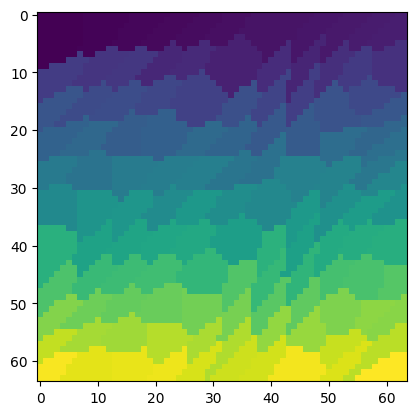

In [58]:
from matplotlib import pyplot as plt
plt.imshow(graph.segments[0])